# Water Quality Prediction: v2 Notebook 
Update:
- Clustering rows by regions using K-means
- GroupKFolds to prevent data leakage
- Random Forest -> LightGBM
- add 10 more features from terraclimate

** 클러스터 기반 결측치

In [23]:
# Suppress warnings
import warnings
warnings.filterwarnings('ignore')

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Data manipulation and analysis
import numpy as np
import pandas as pd

# Multi-dimensional arrays and datasets (e.g., NetCDF, Zarr)
import xarray as xr

# Geospatial raster data handling with CRS support
import rioxarray as rxr

# Raster operations and spatial windowing
import rasterio
from rasterio.windows import Window

# Feature preprocessing and data splitting
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from scipy.spatial import cKDTree

from lightgbm import LGBMRegressor
import optuna
import lightgbm as lgb

# Machine Learning
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error
from sklearn.cluster import KMeans
from sklearn.model_selection import GroupKFold
import numpy as np

# Planetary Computer tools for STAC API access and authentication
import pystac_client
import planetary_computer as pc
from odc.stac import stac_load
from pystac.extensions.eo import EOExtension as eo

from datetime import date
from tqdm import tqdm
import os 

In [24]:
Water_Quality_df=pd.read_csv('./data/water_quality_training_dataset.csv')
print(len(Water_Quality_df))
Water_Quality_df.head()

9319


,Latitude,Longitude,Sample Date,Total Alkalinity,Electrical Conductance,Dissolved Reactive Phosphorus
0,-28.760833,17.730278,02-01-2011,128.912,555.0,10.0
1,-26.861111,28.884722,03-01-2011,74.720,162.9,163.0
2,-26.450000,28.085833,03-01-2011,89.254,573.0,80.0
3,-27.671111,27.236944,03-01-2011,82.000,203.6,101.0
4,-27.356667,27.286389,03-01-2011,56.100,145.1,151.0


In [25]:
landsat_train_features = pd.read_csv('./data/landsat_features_training_plus.csv')
print(len(landsat_train_features))
landsat_train_features.head()

9319


,Latitude,Longitude,Sample Date,nir,green,swir16,swir22,NDMI,MNDWI,ls_blue,ls_red
0,-28.760833,17.730278,02-01-2011,11190.0,11426.0,7687.5,7645.0,0.185538,0.195595,9774.0,12802.0
1,-26.861111,28.884722,03-01-2011,17658.5,9550.0,13746.5,10574.0,0.124566,-0.180134,8495.5,8955.5
2,-26.450000,28.085833,03-01-2011,15210.0,10720.0,17974.0,14201.0,-0.083293,-0.252805,8857.0,10679.0
3,-27.671111,27.236944,03-01-2011,14887.0,10943.0,13522.0,11403.0,0.048048,-0.105416,9590.0,10793.0
4,-27.356667,27.286389,03-01-2011,16828.5,9502.5,12665.5,9643.0,0.141147,-0.142683,8804.0,9402.0


In [26]:
Terraclimate_df = pd.read_csv('./data/terraclimate_features_training.csv')
print(len(Terraclimate_df))
Terraclimate_df.head()

9319


,Latitude,Longitude,Sample Date,pet,ppt,aet,def,pdsi,q,soil,tmax,tmin,vpd
0,-28.760833,17.730278,02-01-2011,174.2,32.7,31.100000,143.100000,3.65,1.6,0.0,36.100000,22.689999,2.92
1,-26.861111,28.884722,03-01-2011,124.1,51.1,53.800000,70.300000,0.66,2.6,12.8,27.160000,13.219999,0.95
2,-26.450000,28.085833,03-01-2011,127.5,62.7,60.800000,66.700005,-1.16,3.1,6.8,27.519999,14.090000,1.02
3,-27.671111,27.236944,03-01-2011,129.7,84.2,83.200005,46.500000,2.84,4.2,7.2,28.869999,14.639999,1.22
4,-27.356667,27.286389,03-01-2011,129.2,78.0,77.300000,51.900000,2.65,3.9,7.8,28.670000,14.690000,1.18


In [27]:
# Combine two datasets vertically (along columns) using pandas concat function.
def combine_two_datasets(dataset1,dataset2,dataset3):
    '''
    Returns a  vertically concatenated dataset.
    Attributes:
    dataset1 - Dataset 1 to be combined 
    dataset2 - Dataset 2 to be combined
    '''
    
    data = pd.concat([dataset1,dataset2,dataset3], axis=1)
    data = data.loc[:, ~data.columns.duplicated()]
    return data

In [28]:
# Combining ground data and final data into a single dataset.
wq_data = combine_two_datasets(Water_Quality_df, landsat_train_features, Terraclimate_df)
    
# wq_data['Total Akalinity'] = np.log1p(wq_data['Total Alkalinity'])
# wq_data['Electrical Conductance'] = np.log1p(wq_data['Electrical Conductance'])
# wq_data['Dissolved Reactive Phosphorus'] = np.log1p(wq_data['Dissolved Reactive Phosphorus'])

print(wq_data.shape)
wq_data.head()

(9319, 24)


,Latitude,Longitude,Sample Date,Total Alkalinity,Electrical Conductance,Dissolved Reactive Phosphorus,nir,green,swir16,swir22,...,pet,ppt,aet,def,pdsi,q,soil,tmax,tmin,vpd
0,-28.760833,17.730278,02-01-2011,128.912,555.0,10.0,11190.0,11426.0,7687.5,7645.0,...,174.2,32.7,31.100000,143.100000,3.65,1.6,0.0,36.100000,22.689999,2.92
1,-26.861111,28.884722,03-01-2011,74.720,162.9,163.0,17658.5,9550.0,13746.5,10574.0,...,124.1,51.1,53.800000,70.300000,0.66,2.6,12.8,27.160000,13.219999,0.95
2,-26.450000,28.085833,03-01-2011,89.254,573.0,80.0,15210.0,10720.0,17974.0,14201.0,...,127.5,62.7,60.800000,66.700005,-1.16,3.1,6.8,27.519999,14.090000,1.02
3,-27.671111,27.236944,03-01-2011,82.000,203.6,101.0,14887.0,10943.0,13522.0,11403.0,...,129.7,84.2,83.200005,46.500000,2.84,4.2,7.2,28.869999,14.639999,1.22
4,-27.356667,27.286389,03-01-2011,56.100,145.1,151.0,16828.5,9502.5,12665.5,9643.0,...,129.2,78.0,77.300000,51.900000,2.65,3.9,7.8,28.670000,14.690000,1.18


## Model Building

<p align="justify"> Now let us select the columns required for our model building exercise. We will consider only Band swir22, NDMI and MNDWI from the Landsat data and pet from Terraclimate dataset as our predictor variables. It does not make sense to use latitude and longitude as predictor variables, as they do not have any direct impact on predicting the water quality parameters.</p>


In [49]:
def kmeans_regions(df, lat_col="Latitude", lon_col="Longitude", n_clusters=20, random_state=42):
    """
    example return: [1 1 1 0 0 0 2 2] when there are 3 clusters and 8 samples.
    """
    km = KMeans(n_clusters=n_clusters, random_state=random_state)
    clusters = km.fit_predict(df[[lat_col, lon_col]].to_numpy())
    return clusters

def region_splits(X, groups, n_splits=5):
    """
    Using GroupKFold, ensure that all samples from the same cluster are put together in either the training or validating set.

    n_splits = 5: train:val = 80:20

    example return:
    Fold1= train_idx:[0 1 2 6 7] + val_idx :[3 4 5]
    Fold2= train_idx:[3 4 5 6 7] + val_idx :[0 1 2]
    Fold3= train_idx:[0 1 2 3 4 5] + val_idx :[6 7]
    """
    gkf = GroupKFold(n_splits=n_splits)
    for train_idx, val_idx in gkf.split(X, groups=groups):
        yield train_idx, val_idx

def fit_median_imputer(X_train):
    # Changed: fit medians only on training fold
    return X_train.median(numeric_only=True)

def apply_median_imputer(X, medians):
    # Changed: apply training medians to any dataset
    return X.fillna(medians)

def impute_by_cluster(X, n_clusters=20, random_state=42):
    """
    클러스터별 중앙값으로 결측치를 채우고, 
    데이터프레임과 클러스터 정보를 반환합니다.
    """
    X_imputed = X.copy()
    
    # 1. 클러스터 생성 (이미 정의하신 kmeans_regions 함수 사용)
    clusters = kmeans_regions(X_imputed, lat_col="Latitude", lon_col="Longitude",
                               n_clusters=n_clusters, random_state=random_state)
    X_imputed['temp_cluster'] = clusters

    # 2. 결측치 컬럼 파악
    cols_with_nan = X_imputed.columns[X_imputed.isna().any()].tolist()
    
    if cols_with_nan:
        # 클러스터별 중앙값으로 채우기
        X_imputed[cols_with_nan] = X_imputed.groupby('temp_cluster')[cols_with_nan].transform(
            lambda x: x.fillna(x.median())
        )
        # 특정 클러스터 전체가 NaN일 경우를 대비해 전체 중앙값으로 최종 보간
        X_imputed[cols_with_nan] = X_imputed[cols_with_nan].fillna(X_imputed[cols_with_nan].median())
    
    # 3. 임시 컬럼 제거
    X_imputed = X_imputed.drop(columns=['temp_cluster'])
    
    return X_imputed, clusters

def feature_engineering(df):
    df = df.copy()
    eps = 1e-10

    dt = pd.to_datetime(df['Sample Date'], dayfirst=True, errors='coerce')
    df['month'] = dt.dt.month
    df['sin_month'] = np.sin(2 * np.pi * df['month'] / 12)
    df['cos_month'] = np.cos(2 * np.pi * df['month'] / 12)

    # Remote sensing: keep only stronger ones
    df['swir1_swir2_ratio'] = df['swir16'] / (df['swir22'] + eps)
    df['green_swir1_diff'] = df['green'] - df['swir16']

    # Climate
    df['ppt_pet_ratio'] = df['ppt'] / (df['pet'] + eps)
    df['aet_pet_ratio'] = df['aet'] / (df['pet'] + eps)
    df['water_surplus'] = df['ppt'] - df['pet']
    df['temp_range'] = df['tmax'] - df['tmin']

    # Spatial
    df['lat2'] = df['Latitude'] ** 2
    df['lon2'] = df['Longitude'] ** 2
    df['lat_lon_interaction'] = df['Latitude'] * df['Longitude']

    df = df.drop(columns=['month', 'Sample Date'])
    return df

In [50]:
def run_pipeline_optuna(X, y, param_name="Parameter", n_trials=80):

    optuna.logging.set_verbosity(optuna.logging.WARNING)

    print(f"Tuning Model for {param_name}")

    X = X.copy()                     # Changed
    X = feature_engineering(X)       # Changed

    clusters = kmeans_regions(
        X,
        lat_col="Latitude",
        lon_col="Longitude",
        n_clusters=20,
        random_state=42
    )

    folds = list(region_splits(X, groups=clusters, n_splits=5))

    def objective(trial):

        params = {
            "n_estimators": trial.suggest_int("n_estimators", 500, 2000),
            "learning_rate": trial.suggest_float("learning_rate", 0.005, 0.1, log=True),
            "num_leaves": trial.suggest_int("num_leaves", 16, 128),
            "max_depth": trial.suggest_int("max_depth", 4, 10),
            "min_child_samples": trial.suggest_int("min_child_samples", 5, 30),
            "subsample": trial.suggest_float("subsample", 0.75, 1.0),
            "colsample_bytree": trial.suggest_float("colsample_bytree", 0.75, 1.0),
            "reg_alpha": trial.suggest_float("reg_alpha", 1e-4, 10.0, log=True),
            "reg_lambda": trial.suggest_float("reg_lambda", 1e-4, 10.0, log=True),
            "random_state": 42,
            "n_jobs": -1,
            "verbosity": -1,
        }

        fold_scores = []

        for fold, (train_idx, val_idx) in enumerate(folds):
            X_train, X_val = X.iloc[train_idx].copy(), X.iloc[val_idx].copy()
            y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

            # Changed: fit imputer on train fold only
            medians = fit_median_imputer(X_train)
            X_train = apply_median_imputer(X_train, medians)
            X_val = apply_median_imputer(X_val, medians)

            model = lgb.LGBMRegressor(**params)

            model.fit(
                X_train,
                y_train,
                eval_set=[(X_val, y_val)],
                callbacks=[lgb.early_stopping(50, verbose=False)]
            )

            preds = model.predict(X_val)
            fold_scores.append(r2_score(y_val, preds))

        return float(np.mean(fold_scores))

    study = optuna.create_study(direction="maximize")
    study.optimize(objective, n_trials=n_trials)

    print("\nBest R2:", study.best_value)
    print("Best Params:", study.best_params)

    best_params = study.best_params
    best_params.update({
        "verbosity": -1,
        "random_state": 42,
        "n_jobs": -1
    })

    # Changed: final preprocessing on full training data
    final_medians = fit_median_imputer(X)
    X_final = apply_median_imputer(X.copy(), final_medians)

    final_model = lgb.LGBMRegressor(**best_params)
    final_model.fit(X_final, y)

    return final_model, study.best_params, study.best_value

In [51]:
X = wq_data.drop(columns=['Total Alkalinity', 'Electrical Conductance', 'Dissolved Reactive Phosphorus'])

print(X.columns.tolist())

['Latitude', 'Longitude', 'Sample Date', 'nir', 'green', 'swir16', 'swir22', 'NDMI', 'MNDWI', 'ls_blue', 'ls_red', 'pet', 'ppt', 'aet', 'def', 'pdsi', 'q', 'soil', 'tmax', 'tmin', 'vpd']


In [52]:
y_TA = wq_data['Total Alkalinity']
y_EC = wq_data['Electrical Conductance']
y_DRP = wq_data['Dissolved Reactive Phosphorus']

model_TA, best_params_TA, r2_TA = run_pipeline_optuna(X, y_TA, "Total Alkalinity", n_trials=80)
model_EC, best_params_EC, r2_EC = run_pipeline_optuna(X, y_EC, "Electrical Conductance", n_trials=80)
model_DRP, best_params_DRP, r2_DRP = run_pipeline_optuna(X, y_DRP, "Dissolved Reactive Phosphorus", n_trials=80)

Tuning Model for Total Alkalinity

Best R2: 0.17014553724578918
Best Params: {'n_estimators': 513, 'learning_rate': 0.038340213923528474, 'num_leaves': 18, 'max_depth': 7, 'min_child_samples': 7, 'subsample': 0.9790918125255897, 'colsample_bytree': 0.8098432103414734, 'reg_alpha': 4.3315011042828875, 'reg_lambda': 6.9397941667664265}
Tuning Model for Electrical Conductance

Best R2: 0.21011816642252068
Best Params: {'n_estimators': 721, 'learning_rate': 0.03628216966804039, 'num_leaves': 24, 'max_depth': 4, 'min_child_samples': 29, 'subsample': 0.7610038394702054, 'colsample_bytree': 0.8271837580162292, 'reg_alpha': 0.006245027789323207, 'reg_lambda': 0.003463973578238047}
Tuning Model for Dissolved Reactive Phosphorus

Best R2: -0.012299125303640857
Best Params: {'n_estimators': 1399, 'learning_rate': 0.06980496390669522, 'num_leaves': 75, 'max_depth': 4, 'min_child_samples': 22, 'subsample': 0.9786663527503835, 'colsample_bytree': 0.8045444001818154, 'reg_alpha': 0.055922337824913626

In [53]:
print(X.isna().sum())
print(X.columns.tolist())
print(X.shape)

Latitude          0
Longitude         0
Sample Date       0
nir            1085
green          1085
swir16         1085
swir22         1085
NDMI           1085
MNDWI          1085
ls_blue         688
ls_red          688
pet               0
ppt               0
aet               0
def               0
pdsi              0
q                 0
soil              0
tmax              0
tmin              0
vpd               0
dtype: int64
['Latitude', 'Longitude', 'Sample Date', 'nir', 'green', 'swir16', 'swir22', 'NDMI', 'MNDWI', 'ls_blue', 'ls_red', 'pet', 'ppt', 'aet', 'def', 'pdsi', 'q', 'soil', 'tmax', 'tmin', 'vpd']
(9319, 21)


### Model Performance Summary

<p align="justify">After training and evaluating the models for each water quality parameter, the individual performance metrics are combined into a single summary table. This table consolidates the R² and RMSE values for both in-sample and out-of-sample evaluations, enabling an easy comparison of model performance across Total Alkalinity, Electrical Conductance, and Dissolved Reactive Phosphorus. Such a summary provides a quick overview of how well each model captures the variability in the respective parameter and highlights any differences in predictive accuracy.</p>

In [54]:
results_summary = pd.DataFrame([  # Changed
    {"Parameter": "Total Alkalinity", "Val_R2": r2_TA, "Best_Params": best_params_TA},  # Changed
    {"Parameter": "Electrical Conductance", "Val_R2": r2_EC, "Best_Params": best_params_EC},  # Changed
    {"Parameter": "Dissolved Reactive Phosphorus", "Val_R2": r2_DRP, "Best_Params": best_params_DRP},  # Changed
])  # Changed

results_summary

,Parameter,Val_R2,Best_Params
0,Total Alkalinity,0.170146,"{'n_estimators': 513, 'learning_rate': 0.03834..."
1,Electrical Conductance,0.210118,"{'n_estimators': 721, 'learning_rate': 0.03628..."
2,Dissolved Reactive Phosphorus,-0.012299,"{'n_estimators': 1399, 'learning_rate': 0.0698..."


## Submission

<p align="justify">Once you are satisfied with your model’s performance, you can proceed to make predictions for unseen data. To do this, use your trained model to estimate the concentrations of the target water quality parameters — Total Alkalinity, Electrical Conductance, and Dissolved Reactive Phosphorus — for a set of test locations provided in the "Submission_template.csv" file. The predicted results can then be uploaded to the challenge platform for evaluation.</p>

In [55]:
#Reading the coordinates for the submission
test_file = pd.read_csv('./data/submission_template.csv')
test_file.head()

,Latitude,Longitude,Sample Date,Total Alkalinity,Electrical Conductance,Dissolved Reactive Phosphorus
0,-32.043333,27.822778,01-09-2014,NaN,NaN,NaN
1,-33.329167,26.077500,16-09-2015,NaN,NaN,NaN
2,-32.991639,27.640028,07-05-2015,NaN,NaN,NaN
3,-34.096389,24.439167,07-02-2012,NaN,NaN,NaN
4,-32.000556,28.581667,01-10-2014,NaN,NaN,NaN


<p align="justify">
Similarly, participants can use the <b>Landsat</b> and <b>TerraClimate</b> data extraction demonstration notebooks to produce feature CSVs for their <b>validation</b> data. For convenience, we have already computed and saved example validation outputs as <code>landsat_features_val_V3.csv</code> and <code>Terraclimate_val_df_v3.csv</code>. Participants should save their own extracted files in the same format and column schema; doing so will allow this benchmark notebook to load the validation features directly and run smoothly.
</p>


In [56]:
landsat_val_features = pd.read_csv('./data/landsat_features_validation_plus.csv')
landsat_val_features.head()

,Latitude,Longitude,Sample Date,nir,green,swir16,swir22,NDMI,MNDWI,ls_blue,ls_red
0,-32.043333,27.822778,01-09-2014,15229.0,12868.0,14797.0,12421.0,0.014388,-0.069727,11282.0,13210.0
1,-33.329167,26.077500,16-09-2015,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,-32.991639,27.640028,07-05-2015,16221.0,9304.5,12536.5,9958.0,0.128123,-0.147979,8111.5,9145.0
3,-34.096389,24.439167,07-02-2012,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,-32.000556,28.581667,01-10-2014,9125.0,11100.5,9455.0,8711.0,-0.017761,0.080052,9504.0,11166.0


In [57]:
Terraclimate_val_df = pd.read_csv('./data/terraclimate_features_validation.csv')
Terraclimate_val_df.head()

,Latitude,Longitude,Sample Date,pet,ppt,aet,def,pdsi,q,soil,tmax,tmin,vpd
0,-32.043333,27.822778,01-09-2014,161.90001,25.6,24.800001,137.10000,-2.12,1.3,4.8,28.750000,15.929999,1.15
1,-33.329167,26.077500,16-09-2015,177.60000,11.6,11.200000,166.40001,-0.85,0.6,2.7,29.340000,15.339999,1.11
2,-32.991639,27.640028,07-05-2015,158.40001,21.5,22.100000,136.30000,-2.24,1.1,12.0,27.390000,17.869999,0.83
3,-34.096389,24.439167,07-02-2012,130.00000,28.2,34.100002,95.90000,2.85,1.4,16.4,23.769999,16.070000,0.44
4,-32.000556,28.581667,01-10-2014,152.50000,27.2,26.400000,126.10000,-2.34,1.4,5.1,27.800000,16.560000,0.89


In [58]:
tc_keys = ['Latitude', 'Longitude', 'Sample Date']

# Changed: build validation features with all required Landsat columns including ls_blue, ls_red
val_data = (
    landsat_val_features[
        [
            'Longitude', 'Latitude', 'Sample Date',
            'nir', 'green', 'swir16', 'swir22',
            'NDMI', 'MNDWI',
            'ls_blue', 'ls_red'   # Changed
        ]
    ]
    .merge(
        Terraclimate_val_df[
            tc_keys + ['pet', 'ppt', 'aet', 'def', 'pdsi', 'q', 'soil', 'tmax', 'tmin', 'vpd']
        ],
        on=tc_keys,
        how='left',
        validate='one_to_one'
    )
)

# Changed: build train-side engineered columns first, then reuse them for validation
X_train_fe = feature_engineering(X.copy())          # Changed
feature_cols = X_train_fe.columns.tolist()          # Changed

# Changed: apply the same feature engineering to validation
val_data = feature_engineering(val_data)

# Changed: use TRAIN medians, not validation medians
train_medians = fit_median_imputer(X_train_fe)      # Changed
val_data = apply_median_imputer(val_data, train_medians)   # Changed

# Changed: align validation columns to training feature columns
val_data = val_data.reindex(columns=feature_cols)

submission_val_data = val_data.copy()

# Changed: stronger sanity checks
print("Validation data columns:", val_data.columns.tolist())
print("val_data shape:", val_data.shape)
print("Missing columns:", sorted(set(feature_cols) - set(val_data.columns)))   # Changed
print("Extra columns:", sorted(set(val_data.columns) - set(feature_cols)))     # Changed
print("Any NaN left:", val_data.isna().sum().sum())                            # Changed

Validation data columns: ['Latitude', 'Longitude', 'nir', 'green', 'swir16', 'swir22', 'NDMI', 'MNDWI', 'ls_blue', 'ls_red', 'pet', 'ppt', 'aet', 'def', 'pdsi', 'q', 'soil', 'tmax', 'tmin', 'vpd', 'sin_month', 'cos_month', 'swir1_swir2_ratio', 'green_swir1_diff', 'ppt_pet_ratio', 'aet_pet_ratio', 'water_surplus', 'temp_range', 'lat2', 'lon2', 'lat_lon_interaction']
val_data shape: (200, 31)
Missing columns: []
Extra columns: []
Any NaN left: 0


In [59]:
print(submission_val_data.isna().sum())

Latitude               0
Longitude              0
nir                    0
green                  0
swir16                 0
swir22                 0
NDMI                   0
MNDWI                  0
ls_blue                0
ls_red                 0
pet                    0
ppt                    0
aet                    0
def                    0
pdsi                   0
q                      0
soil                   0
tmax                   0
tmin                   0
vpd                    0
sin_month              0
cos_month              0
swir1_swir2_ratio      0
green_swir1_diff       0
ppt_pet_ratio          0
aet_pet_ratio          0
water_surplus          0
temp_range             0
lat2                   0
lon2                   0
lat_lon_interaction    0
dtype: int64


In [60]:
print("train features:", len(feature_cols), feature_cols[:5], "...")  # optional
print("submission features:", submission_val_data.shape[1])           # optional

train features: 31 ['Latitude', 'Longitude', 'nir', 'green', 'swir16'] ...
submission features: 31


In [61]:
pred_TA_submission = model_TA.predict(submission_val_data)
pred_EC_submission = model_EC.predict(submission_val_data)
pred_DRP_submission = model_DRP.predict(submission_val_data)

# pred_TA_final = np.expm1(pred_TA_submission)
# pred_EC_final = np.expm1(pred_EC_submission)
# pred_DRP_final = np.expm1(pred_DRP_submission)

In [62]:
submission_df = pd.DataFrame({
    'Longitude': test_file['Longitude'], 
    'Latitude': test_file['Latitude'],   
    'Sample Date': test_file['Sample Date'], 
    'Total Alkalinity': pred_TA_submission,
    'Electrical Conductance': pred_EC_submission,
    'Dissolved Reactive Phosphorus': pred_DRP_submission
})

In [63]:
#Displaying the sample submission dataframe
submission_df.head()

,Longitude,Latitude,Sample Date,Total Alkalinity,Electrical Conductance,Dissolved Reactive Phosphorus
0,27.822778,-32.043333,01-09-2014,73.183611,221.685665,17.268950
1,26.077500,-33.329167,16-09-2015,186.059104,627.766658,50.215309
2,27.640028,-32.991639,07-05-2015,66.297787,263.786380,18.387768
3,24.439167,-34.096389,07-02-2012,16.190646,360.986836,23.071027
4,28.581667,-32.000556,01-10-2014,62.850440,166.689627,15.138158


In [64]:
#Dumping the predictions into a csv file.
submission_df.to_csv("./submission/v4.csv",index = False)

In [65]:
importance_TA = pd.DataFrame({
    "feature": submission_val_data.columns,
    "gain": model_TA.booster_.feature_importance(importance_type="gain"),
    "split": model_TA.booster_.feature_importance(importance_type="split")
}).sort_values("gain", ascending=False)

print("TA Feature Importance")
print(importance_TA.head(25))

TA Feature Importance
                feature          gain  split
1             Longitude  1.200431e+08    923
0              Latitude  1.147119e+08    995
16                 soil  1.125689e+08    429
28                 lat2  4.611353e+07    226
29                 lon2  4.145455e+07    201
30  lat_lon_interaction  4.011500e+07    711
7                 MNDWI  1.821530e+07    306
18                 tmin  1.608019e+07    470
19                  vpd  1.095947e+07    244
6                  NDMI  9.499654e+06    286
27           temp_range  9.387778e+06    288
5                swir22  8.698403e+06    163
20            sin_month  7.679684e+06    219
14                 pdsi  6.000845e+06    402
17                 tmax  5.299434e+06    242
2                   nir  5.280454e+06    193
10                  pet  5.000642e+06    272
22    swir1_swir2_ratio  4.772626e+06    228
23     green_swir1_diff  4.351153e+06    103
21            cos_month  4.253775e+06    227
9                ls_red  3.297595

In [66]:
importance_EC = pd.DataFrame({
    "feature": submission_val_data.columns,
    "gain": model_EC.booster_.feature_importance(importance_type="gain"),
    "split": model_EC.booster_.feature_importance(importance_type="split")
}).sort_values("gain", ascending=False)

print("EC Feature Importance")
print(importance_EC.head(25))

EC Feature Importance
                feature          gain  split
30  lat_lon_interaction  4.075494e+09    677
1             Longitude  2.947596e+09    858
0              Latitude  2.297512e+09   1154
16                 soil  7.272562e+08    448
29                 lon2  6.654935e+08    163
28                 lat2  4.373264e+08    169
18                 tmin  2.623555e+08    355
14                 pdsi  2.524314e+08    320
19                  vpd  2.269032e+08    291
5                swir22  1.739682e+08    121
6                  NDMI  1.716706e+08    227
17                 tmax  1.464197e+08    207
20            sin_month  1.381600e+08    196
10                  pet  1.339857e+08    268
7                 MNDWI  1.200369e+08    230
22    swir1_swir2_ratio  1.143748e+08    252
27           temp_range  9.109931e+07    282
13                  def  7.602916e+07    208
23     green_swir1_diff  7.328264e+07    160
4                swir16  6.740766e+07    113
21            cos_month  5.822395

In [67]:
importance_DRP = pd.DataFrame({
    "feature": submission_val_data.columns,
    "gain": model_DRP.booster_.feature_importance(importance_type="gain"),
    "split": model_DRP.booster_.feature_importance(importance_type="split")
}).sort_values("gain", ascending=False)

print("DRP Feature Importance")
print(importance_DRP.head(25))

DRP Feature Importance
                feature          gain  split
0              Latitude  3.580073e+07    896
1             Longitude  3.315834e+07    473
28                 lat2  1.399545e+07    162
30  lat_lon_interaction  9.513107e+06    616
10                  pet  5.556430e+06    636
29                 lon2  5.549809e+06     80
19                  vpd  3.825044e+06    543
18                 tmin  3.446471e+06    706
16                 soil  3.215711e+06    510
27           temp_range  3.109468e+06    640
14                 pdsi  3.015198e+06    759
6                  NDMI  2.870912e+06    827
17                 tmax  2.832727e+06    523
25        aet_pet_ratio  2.611810e+06    225
22    swir1_swir2_ratio  2.547835e+06    796
2                   nir  2.288702e+06    773
21            cos_month  2.168029e+06    560
5                swir22  2.086738e+06    627
7                 MNDWI  2.012756e+06    736
20            sin_month  1.820101e+06    451
3                 green  1.78973

<Figure size 600x400 with 0 Axes>

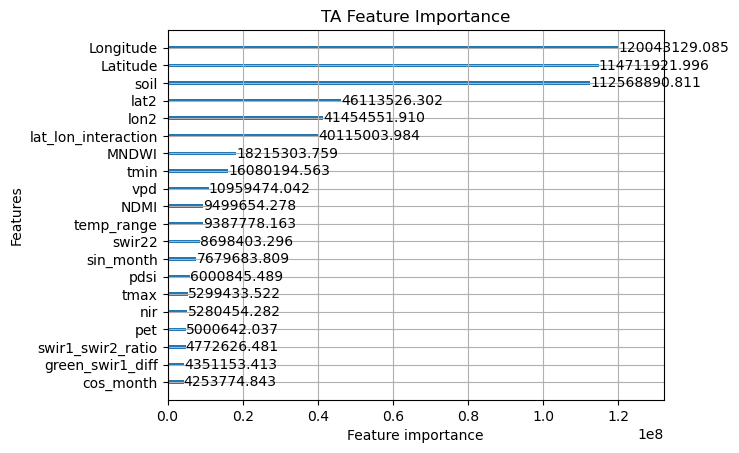

<Figure size 600x400 with 0 Axes>

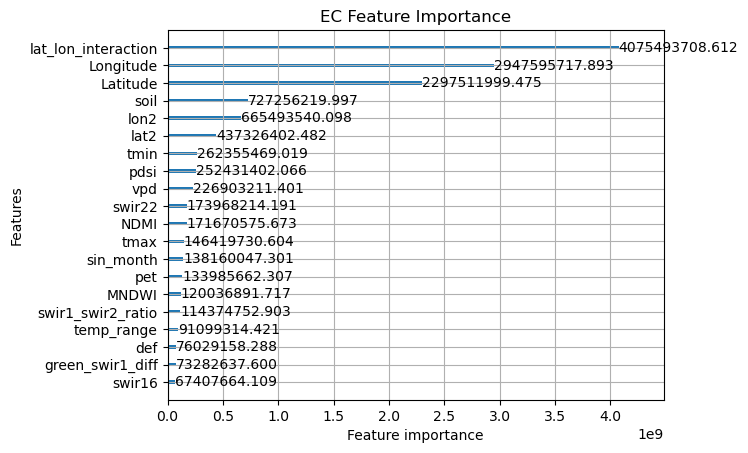

<Figure size 600x400 with 0 Axes>

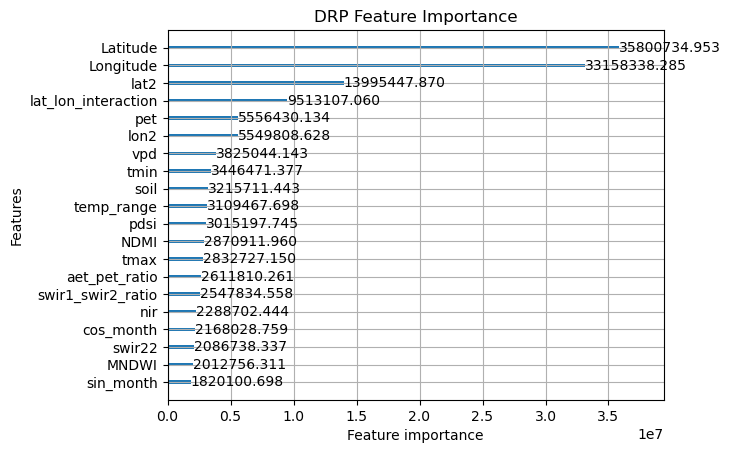

In [68]:
plt.figure(figsize=(6,4))
lgb.plot_importance(model_TA, importance_type="gain", max_num_features=20)
plt.title("TA Feature Importance")
plt.show()

plt.figure(figsize=(6,4))
lgb.plot_importance(model_EC, importance_type="gain", max_num_features=20)
plt.title("EC Feature Importance")
plt.show()

plt.figure(figsize=(6,4))
lgb.plot_importance(model_DRP, importance_type="gain", max_num_features=20)
plt.title("DRP Feature Importance")
plt.show()